# Módulo III: Big Data y la Analítica de Datos para la Toma de Decisiones
## Unidad III: Introducción a Redes Neuronales y Deep Learning
### **Notebook Formativo 6: Fundamentos de Redes Neuronales y Perceptrón Multicapa (MLP)**

**Caso:** clasificación anticipada de desviaciones térmicas en transporte refrigerado (AndinaLog 03B — Contrato 2)  
**Diplomado:** Gestión Industrial y Analítica de Datos — FCyT UMSS

---

## Propósito y evidencia de aprendizaje

Este notebook guía un experimento de clasificación binaria con Keras/TensorFlow aplicado a la telemetría IoT del Proyecto Integrador. Al finalizar, podrá:

1. Formular un contrato predictivo y excluir variables con fuga de información.
2. Aplicar un corte temporal **train/validation/test** antes de aprender cualquier parámetro de preparación.
3. Ajustar imputación y escalamiento solo con entrenamiento.
4. Comparar una MLP pequeña contra un baseline reproducible.
5. Interpretar curvas de aprendizaje, métricas y matriz de confusión sin abrir el conjunto de prueba.

> **Evidencia del día:** Notebook 6 ejecutable y documentado + contrato MLP actualizado del Proyecto Integrador.

## 0. Inicialización del entorno

Configuramos las bibliotecas y fijamos semillas. La semilla mejora la reproducibilidad, aunque diferentes versiones, dispositivos o kernels pueden producir pequeñas variaciones numéricas.

> Ejecute este notebook preferentemente en **Google Colab**. TensorFlow viene preinstalado en los runtimes estándar; evite instalar versiones distintas durante la clase salvo indicación docente.

In [18]:
import os
import sys
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
except ImportError as exc:
    raise ImportError(
        "Este notebook requiere TensorFlow. Ábralo en Google Colab o use un entorno "
        "con TensorFlow/Keras instalado."
    ) from exc

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (10, 5), "axes.titlesize": 13, "axes.labelsize": 11})

SEMILLA = 42
random.seed(SEMILLA)
np.random.seed(SEMILLA)
tf.keras.utils.set_random_seed(SEMILLA)

keras_version = getattr(keras, "__version__", "integrada en TensorFlow")
print("Entorno preparado.")
print(f"Python {sys.version.split()[0]} | TensorFlow {tf.__version__} | Keras {keras_version}")

Entorno preparado.
Python 3.13.15 | TensorFlow 2.20.0 | Keras 3.13.2


## 1. Carga controlada del dataset Silver

El archivo esperado es **andinalog_iot_telemetry_silver.csv** de la capa curada de telemetría IoT. El código busca el archivo real en rutas locales y de Colab/Drive.

In [19]:
DATASET_NAME = "andinalog_iot_telemetry_didactico_v2_silver.csv" ##nombre del documento silver
USAR_DATOS_DEMO_SI_FALTA_ARCHIVO = False

rutas_busqueda = [
    DATASET_NAME,
    f"./{DATASET_NAME}",
    f"../{DATASET_NAME}",
    f"/content/{DATASET_NAME}",
    f"/content/drive/MyDrive/{DATASET_NAME}",
    f"/content/drive/MyDrive/GIAD/{DATASET_NAME}",
    f"datasets/AndinaLog_03B_Bronce/{DATASET_NAME}",
    f"proyecto-integrador/andinalog_iot_telemetry/notebook2/salidas/{DATASET_NAME}",
    f"S4/andinalog_iot_telemetry/notebook2/salidas/{DATASET_NAME}",
]

ruta_detectada = next((ruta for ruta in rutas_busqueda if os.path.exists(ruta)), None)

if ruta_detectada:
    MODO_DATOS = "REAL"
    print(f"Cargando dataset real: {ruta_detectada}")
    df_silver = pd.read_csv(ruta_detectada)
else:
    raise FileNotFoundError(
        f"No se encontró {DATASET_NAME}. Coloque el archivo en el directorio o en Google Drive."
    )

print(f"Modo de datos: {MODO_DATOS}")
print(f"Dimensiones: {df_silver.shape[0]} filas × {df_silver.shape[1]} columnas")
df_silver.head(3)

Cargando dataset real: andinalog_iot_telemetry_didactico_v2_silver.csv
Modo de datos: REAL
Dimensiones: 28677 filas × 55 columnas


,fila_bronze,timestamp,viaje_id,order_id,camion_id,producto_id,temperatura_cabina_c,temp_unit,humedad_cabina_pct,desviacion_termica_flag,desviacion_proximos_60min_flag,timestamp_en_cuarentena,timestamp_motivo,viaje_id_en_cuarentena,viaje_id_motivo,...,timestamp_bolivia_tratado,temperatura_imputada,humedad_imputada,motivo_cuarentena_final,en_cuarentena_final,decision_tratamiento,umbral_producto_evaluable,flag_termico_coherente,apta_kpi_termico,categoria_producto_maestro,tipo_camion_maestro,compatibilidad_tipo_camion_estado,posible_incompatibilidad_termica,compatibilidad_tipo_camion_motivo,apta_objetivo_60min
0,1,2026-08-11 14:11:00,VIA-00001,ORD-2026-05710,CAM-20,PROD-045,2.190,C,72.600,0,0,False,NaN,False,NaN,...,2026-08-11 14:11:00,False,False,NaN,False,SILVER,True,True,True,Fresco,Refrigerado,SIN_ALERTA,False,NaN,True
1,2,2026-08-11 14:41:00,VIA-00001,ORD-2026-05710,CAM-20,PROD-045,4.910,C,75.000,0,0,False,NaN,False,NaN,...,2026-08-11 14:41:00,False,False,NaN,False,SILVER,True,True,True,Fresco,Refrigerado,SIN_ALERTA,False,NaN,True
2,3,2026-08-11 15:11:00,VIA-00001,ORD-2026-05710,CAM-20,PROD-045,2.760,C,94.700,0,0,False,NaN,False,NaN,...,2026-08-11 15:11:00,False,False,NaN,False,SILVER,True,True,True,Fresco,Refrigerado,SIN_ALERTA,False,NaN,True


### Auditoría mínima antes de modelar

Verificamos esquema, marcas de tiempo, identificadores, objetivo y prevalencia. Un dataset Silver debe fallar de manera explícita si no cumple el contrato; no conviene que el notebook continúe silenciosamente.

In [20]:
TARGET = "desviacion_proximos_60min_flag"
VARIABLES_PREDICTORAS = [
    "temperatura_cabina_c",
    "humedad_cabina_pct",
]
FUGAS = ["desviacion_termica_flag"]
IDENTIFICADORES = ["viaje_id", "timestamp", "order_id", "camion_id", "producto_id", "temp_unit"]

columnas_requeridas = set(VARIABLES_PREDICTORAS + [TARGET] + FUGAS + IDENTIFICADORES)
faltantes = columnas_requeridas.difference(df_silver.columns)
assert not faltantes, f"Faltan columnas requeridas: {sorted(faltantes)}"

df_silver = df_silver.copy()
df_silver["timestamp_utc"] = pd.to_datetime(df_silver["timestamp"], utc=True, errors="coerce")
assert df_silver["timestamp_utc"].notna().all(), "Existen timestamp inválidos."

# Creación de registro_id único a partir de viaje_id y timestamp
df_silver["registro_id"] = df_silver["viaje_id"].astype(str) + "_" + df_silver["timestamp"].astype(str)
assert not df_silver["registro_id"].duplicated().any(), "Existen registro_id duplicados."
assert df_silver[TARGET].notna().all(), "La variable objetivo contiene nulos."
assert set(df_silver[TARGET].astype(int).unique()).issubset({0, 1}), "El objetivo debe ser binario."

df_silver[TARGET] = df_silver[TARGET].astype(int)
df_silver = df_silver.sort_values("timestamp_utc").reset_index(drop=True)

distribucion = df_silver[TARGET].value_counts().sort_index().rename(index={0: "Sin desviación", 1: "Desviación 60min"})
print(distribucion.to_string())
print(f"Prevalencia de desviación térmica futura: {df_silver[TARGET].mean():.1%}")
print("Nulos por predictor:")
print(df_silver[VARIABLES_PREDICTORAS].isna().sum().to_string())

desviacion_proximos_60min_flag
Sin desviación      27355
Desviación 60min     1322
Prevalencia de desviación térmica futura: 4.6%
Nulos por predictor:
temperatura_cabina_c    40
humedad_cabina_pct      82


## 2. Contrato predictivo y control de fuga

- **Decisión:** alertar si un camión superará el umbral térmico en la próxima hora para decidir una intercepción o ajuste preventivo.
- **Unidad de observación:** una lectura de telemetría IoT de un viaje.
- **Objetivo:** **desviacion_proximos_60min_flag** (0 = temperatura en rango; 1 = excursión térmica futura en ≤ 60 min).
- **Horizonte:** próximos 60 minutos.
- **Predictores:** mediciones sensoriales disponibles al momento de la lectura.

La columna **desviacion_termica_flag** describe el evento concurrente actual y se excluye por fuga hacia el futuro. Los identificadores operativos tampoco se utilizan como variables numéricas predictoras.

In [21]:
assert not set(FUGAS).intersection(VARIABLES_PREDICTORAS)
assert not set(IDENTIFICADORES).intersection(VARIABLES_PREDICTORAS)

nulos_antes_conversion = df_silver[VARIABLES_PREDICTORAS].isna().sum()
X_all = df_silver[VARIABLES_PREDICTORAS].apply(pd.to_numeric, errors="coerce")
nulos_despues_conversion = X_all.isna().sum()
coerciones_invalidas = nulos_despues_conversion - nulos_antes_conversion
if (coerciones_invalidas > 0).any():
    detalle = coerciones_invalidas[coerciones_invalidas > 0].to_dict()
    raise ValueError(f"Se detectaron tokens no numéricos en la Capa Silver: {detalle}")

y_all = df_silver[TARGET].copy()

print("X disponible al inferir:", VARIABLES_PREDICTORAS)
print("y:", TARGET)
print("Variables excluidas por fuga:", FUGAS)

X disponible al inferir: ['temperatura_cabina_c', 'humedad_cabina_pct']
y: desviacion_proximos_60min_flag
Variables excluidas por fuga: ['desviacion_termica_flag']


## 3. Partición tripartita respetando el tiempo

Como la telemetría tiene orden temporal, un corte aleatorio permitiría que lecturas futuras aparezcan en entrenamiento. Aplicamos un corte cronológico de **64% train, 16% validation y 20% test**.

El conjunto de prueba se reserva para la evaluación final del experimento. En esta sesión solo trabajaremos con train y validation.

In [22]:
n = len(df_silver)
fin_train = int(n * 0.64)
fin_val = int(n * 0.80)

X_train_raw, y_train = X_all.iloc[:fin_train].copy(), y_all.iloc[:fin_train].copy()
X_val_raw, y_val = X_all.iloc[fin_train:fin_val].copy(), y_all.iloc[fin_train:fin_val].copy()
X_test_raw, y_test = X_all.iloc[fin_val:].copy(), y_all.iloc[fin_val:].copy()

ts_train = df_silver.loc[X_train_raw.index, "timestamp_utc"]
ts_val = df_silver.loc[X_val_raw.index, "timestamp_utc"]
ts_test = df_silver.loc[X_test_raw.index, "timestamp_utc"]

assert ts_train.max() < ts_val.min() < ts_test.min(), "El corte temporal no quedó ordenado."
assert set(X_train_raw.index).isdisjoint(X_val_raw.index)
assert set(X_train_raw.index).isdisjoint(X_test_raw.index)
assert set(X_val_raw.index).isdisjoint(X_test_raw.index)

for nombre, X_part, y_part, ts_part in [
    ("TRAIN", X_train_raw, y_train, ts_train),
    ("VALIDATION", X_val_raw, y_val, ts_val),
    ("TEST (SELLADO)", X_test_raw, y_test, ts_test),
]:
    print(
        f"{nombre:14s}: {len(X_part):5d} registros | desviación={y_part.mean():.1%} | "
        f"{ts_part.min()} → {ts_part.max()}"
    )

assert y_train.nunique() == 2 and y_val.nunique() == 2, (
    "Train y validation deben contener ambas clases; revise el horizonte o el corte."
)

TRAIN         : 18353 registros | desviación=4.6% | 2026-08-01 00:10:00+00:00 → 2026-08-20 04:13:00+00:00
VALIDATION    :  4588 registros | desviación=3.2% | 2026-08-20 04:14:00+00:00 → 2026-08-25 03:24:00+00:00
TEST (SELLADO):  5736 registros | desviación=5.8% | 2026-08-25 03:24:00+00:00 → 2026-08-31 11:11:00+00:00


## 4. Imputación segura: aprender solo de train

La mediana es una decisión didáctica razonable para vacíos puntuales, pero no es universal. Debe justificarse desde la física del proceso. El imputador se ajusta **después del corte** y únicamente con entrenamiento.

In [23]:
imputador = SimpleImputer(strategy="median")

X_train_i = pd.DataFrame(
    imputador.fit_transform(X_train_raw),
    columns=VARIABLES_PREDICTORAS,
    index=X_train_raw.index,
)
X_val_i = pd.DataFrame(
    imputador.transform(X_val_raw),
    columns=VARIABLES_PREDICTORAS,
    index=X_val_raw.index,
)
X_test_i = pd.DataFrame(
    imputador.transform(X_test_raw),
    columns=VARIABLES_PREDICTORAS,
    index=X_test_raw.index,
)

assert X_train_i.notna().all().all()
assert X_val_i.notna().all().all()
assert X_test_i.notna().all().all()

medianas_train = pd.Series(imputador.statistics_, index=VARIABLES_PREDICTORAS, name="mediana_train")
display(medianas_train.to_frame())

,mediana_train
temperatura_cabina_c,16.625
humedad_cabina_pct,59.100


## 5. Escalamiento seguro

**StandardScaler** centra y escala usando estadísticas de train. Validation y test reciben exactamente la misma transformación. No es obligatorio para todos los algoritmos, pero es un punto de partida apropiado para una MLP con variables físicas de magnitudes distintas.

In [24]:
scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train_i)
X_val_s = scaler.transform(X_val_i)
X_test_s = scaler.transform(X_test_i)  # Preparado, pero no evaluado en esta sesión.

assert np.isfinite(X_train_s).all()
assert np.isfinite(X_val_s).all()
assert np.isfinite(X_test_s).all()

auditoria_scaler = pd.DataFrame({
    "media_train": scaler.mean_,
    "escala_train": scaler.scale_,
}, index=VARIABLES_PREDICTORAS)
display(auditoria_scaler)

,media_train,escala_train
temperatura_cabina_c,6.091,52.335
humedad_cabina_pct,61.041,15.665


## 6. Baseline: la complejidad debe ganarse

El **DummyClassifier** por clase mayoritaria establece una referencia mínima. En eventos poco frecuentes, accuracy puede ser alta aunque el modelo no detecte ninguna falla; por eso reportamos también precision, recall, F1 y PR-AUC.

In [25]:
def metricas_binarias(y_real, y_pred, prob_pos):
    return pd.Series({
        "accuracy": accuracy_score(y_real, y_pred),
        "precision": precision_score(y_real, y_pred, zero_division=0),
        "recall": recall_score(y_real, y_pred, zero_division=0),
        "f1": f1_score(y_real, y_pred, zero_division=0),
        "pr_auc": average_precision_score(y_real, prob_pos),
    })

baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train_s, y_train)

pred_val_base = baseline.predict(X_val_s)
prob_val_base = baseline.predict_proba(X_val_s)[:, 1]
metricas_base = metricas_binarias(y_val, pred_val_base, prob_val_base)

display(metricas_base.rename("DummyClassifier").to_frame())

,DummyClassifier
accuracy,0.968
precision,0.000
recall,0.000
f1,0.000
pr_auc,0.032


## 7. MLP inicial, pequeña y auditable

La red 32→16 es una hipótesis de partida, no una arquitectura óptima. ReLU introduce no linealidad en las capas ocultas. La salida sigmoide corresponde específicamente a clasificación binaria.

El modelo debe compararse con el baseline y con el mejor modelo clásico de la Unidad II antes de justificar mayor complejidad.

In [26]:
model = keras.Sequential([
    keras.Input(shape=(X_train_s.shape[1],), name="entrada_telemetria"),
    layers.Dense(32, activation="relu", name="oculta_1"),
    layers.Dense(16, activation="relu", name="oculta_2"),
    layers.Dense(1, activation="sigmoid", name="probabilidad_falla"),
], name="MLP_Fallas_Planta")

model.summary()
print(f"Parámetros entrenables: {model.count_params():,}")
print(f"Registros de entrenamiento: {len(X_train_s):,}")

Model: "MLP_Fallas_Planta"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ oculta_1 (Dense)                │ (None, 32)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ oculta_2 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ probabilidad_falla (Dense)      │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 641 (2.50 KB)

 Trainable params: 641 (2.50 KB)

 Non-trainable params: 0 (0.00 B)

Parámetros entrenables: 641
Registros de entrenamiento: 18,353


## 8. Compilación: contrato de aprendizaje

- **Adam:** punto de partida para actualizar pesos; no garantiza el mejor resultado.
- **Binary crossentropy:** pérdida coherente con una etiqueta binaria.
- **Precision, recall y PR-AUC:** métricas útiles ante fallas minoritarias. Accuracy se conserva solo como referencia.

In [27]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.BinaryAccuracy(name="accuracy"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        keras.metrics.AUC(name="pr_auc", curve="PR"),
    ],
)

print("Modelo compilado.")

Modelo compilado.


## 9. Entrenamiento inicial y monitoreo

Entrenamos 20 épocas para observar el comportamiento sin aplicar todavía parada temprana. Validation monitorea la generalización y **no actualiza los pesos**. EarlyStopping y regularización se abordarán en la Sesión 10.

In [14]:
historial = model.fit(
    X_train_s,
    y_train,
    validation_data=(X_val_s, y_val),
    epochs=20,
    batch_size=32,
    verbose=0,
)

historial_df = pd.DataFrame(historial.history)
mejor_epoca = int(historial_df["val_loss"].idxmin() + 1)
print(f"Entrenamiento completado: {len(historial_df)} épocas.")
print(f"Mejor val_loss observado en la época {mejor_epoca}.")
historial_df.tail(3)

Entrenamiento completado: 20 épocas.
Mejor val_loss observado en la época 20.


,accuracy,loss,pr_auc,precision,recall,val_accuracy,val_loss,val_pr_auc,val_precision,val_recall
17,0.954,0.167,0.216,0.000,0.000,0.968,0.127,0.172,0.000,0.000
18,0.954,0.165,0.223,0.000,0.000,0.968,0.126,0.175,0.000,0.000
19,0.954,0.165,0.233,0.000,0.000,0.968,0.126,0.180,0.000,0.000


### Curvas de aprendizaje

- Si train y validation mejoran juntas, existe evidencia de aprendizaje compartido.
- Si train continúa mejorando mientras validation empeora de forma sostenida, sospechamos sobreajuste.
- Una sola oscilación no basta para concluir; observe tendencia, magnitud y estabilidad.

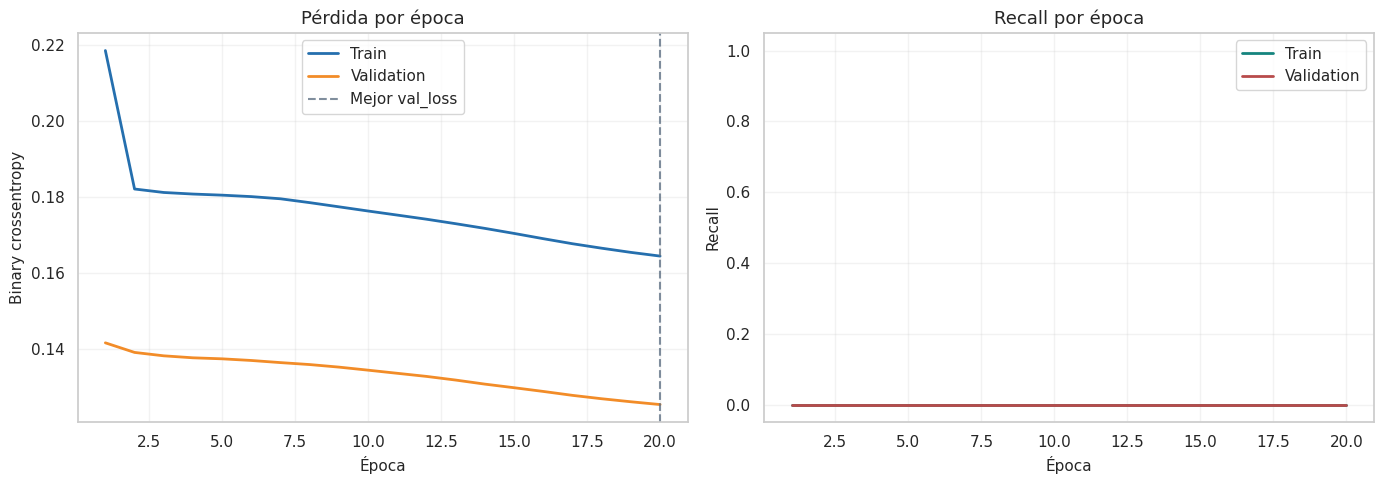

In [15]:
epocas = np.arange(1, len(historial_df) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epocas, historial_df["loss"], label="Train", color="#256FAE", linewidth=2)
axes[0].plot(epocas, historial_df["val_loss"], label="Validation", color="#F28C28", linewidth=2)
axes[0].axvline(mejor_epoca, color="#607285", linestyle="--", alpha=0.8, label="Mejor val_loss")
axes[0].set(title="Pérdida por época", xlabel="Época", ylabel="Binary crossentropy")
axes[0].legend()

axes[1].plot(epocas, historial_df["recall"], label="Train", color="#15847E", linewidth=2)
axes[1].plot(epocas, historial_df["val_recall"], label="Validation", color="#B84B4B", linewidth=2)
axes[1].set(title="Recall por época", xlabel="Época", ylabel="Recall")
axes[1].set_ylim(-0.05, 1.05)
axes[1].legend()

for ax in axes:
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

## 10. Inferencia preliminar en validation

El umbral 0,50 es únicamente una referencia inicial. No debe convertirse en regla de parada de planta sin analizar los costos de falsos negativos y falsos positivos. El conjunto de prueba permanece sellado.

In [16]:
prob_val_mlp = model.predict(X_val_s, verbose=0).ravel()
UMBRAL_INICIAL = 0.50
pred_val_mlp = (prob_val_mlp >= UMBRAL_INICIAL).astype(int)

metricas_mlp = metricas_binarias(y_val, pred_val_mlp, prob_val_mlp)
comparacion = pd.concat(
    [metricas_base.rename("DummyClassifier"), metricas_mlp.rename("MLP")],
    axis=1,
).T

print(f"Métricas en VALIDATION con umbral={UMBRAL_INICIAL:.2f}")
display(comparacion.style.format("{:.3f}"))

assert "X_test_s" in globals(), "El test debe estar preparado pero no evaluado."
print("TEST permanece sellado: no se calcularon predicciones ni métricas de prueba.")

Métricas en VALIDATION con umbral=0.50


,accuracy,precision,recall,f1,pr_auc
DummyClassifier,0.968,0.000,0.000,0.000,0.032
MLP,0.968,0.000,0.000,0.000,0.183


TEST permanece sellado: no se calcularon predicciones ni métricas de prueba.


### Matriz de confusión y reporte por clase

La matriz separa falsas alarmas de fallas no detectadas. En mantenimiento predictivo, ambos errores tienen costos distintos; la métrica prioritaria debe definirse desde el riesgo operativo.

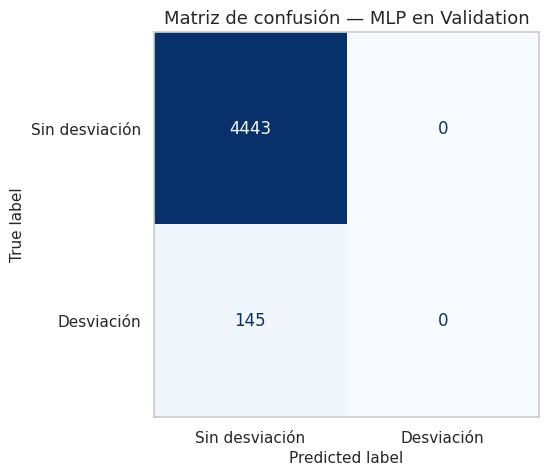

                precision    recall  f1-score   support

Sin desviación       0.97      1.00      0.98      4443
    Desviación       0.00      0.00      0.00       145

      accuracy                           0.97      4588
     macro avg       0.48      0.50      0.49      4588
  weighted avg       0.94      0.97      0.95      4588



In [17]:
matriz = confusion_matrix(y_val, pred_val_mlp, labels=[0, 1])
disp = ConfusionMatrixDisplay(matriz, display_labels=["Sin desviación", "Desviación"])
disp.plot(cmap="Blues", values_format="d", colorbar=False)
plt.title("Matriz de confusión — MLP en Validation")
plt.grid(False)
plt.show()

print(classification_report(
    y_val,
    pred_val_mlp,
    labels=[0, 1],
    target_names=["Sin desviación", "Desviación"],
    zero_division=0,
))

## 11. Pausa de análisis crítico

Responda con criterio de planta:

1. ¿Qué costo operativo tendría un falso negativo y qué costo tendría un falso positivo?
2. Si accuracy es 91% pero recall de fallas es 31%, ¿qué tan útil es el modelo para la decisión propuesta?
3. ¿Qué evidencia necesitaría para afirmar que la MLP aporta más valor que el baseline y el mejor modelo clásico?
4. ¿Qué variable del dataset podría no estar disponible realmente al momento de inferir?

> **Respuesta del participante:**
> 1. **Costos operativos en AndinaLog 03B:**
>    - **Falso Negativo (FN):** No alertar una desviación térmica inminente. Causa la pérdida total de la carga perecedera o farmacéutica, reclamos de clientes, multas contractuales severas y rotura de la cadena de frío.
>    - **Falso Positivo (FP):** Emitir una falsa alarma. Supone el costo operativo menor de ordenar una llamada al transportista, revisar el equipo de refrigeración o programar una parada preventiva breve en un centro logístico cercano.
> 2. **Utilidad de Accuracy frente a Recall:**
>    En este dataset la prevalencia de desviación es de apenas ~4.6%[cite: 13]. Un modelo trivial puede predecir siempre "sin desviación" y lograr >95% de accuracy, pero tendría recall 0%. Si un modelo alcanza 91% de accuracy con 31% de recall, sigue perdiendo el 69% de las desviaciones térmicas reales, resultando insuficiente para evitar pérdidas millonarias de mercadería.
> 3. **Evidencia para justificar la MLP:**
>    Debe demostrar en el conjunto de **Validation** un incremento significativo y sostenido en **PR-AUC**, **Recall** y **F1-Score** sobre la clase 1 respecto al DummyClassifier y al modelo clásico de referencia (Random Forest / Regresión Logística de la Unidad II), sin degradar excesivamente la precisión ni presentar sobreajuste en las curvas de pérdida.
> 4. **Variables potencialmente no disponibles o con fuga:**
>    - `desviacion_termica_flag`: Representa la condición térmica concurrente inmediata y no debe utilizarse como predictora para la alerta futura de 60 minutos sin validar previamente su disponibilidad en tiempo real en la telemetría del camión[cite: 1].

## 12. Aplicación al Proyecto Integrador

Complete el contrato antes de modificar capas:

| Campo | Definición del equipo |
|---|---|
| Decisión que mejorará | Alertar si un camión superará el umbral térmico en la próxima hora para decidir un desvío, ajuste de termostato o intercepción en ruta[cite: 1]. |
| Unidad de observación | Una lectura de telemetría IoT de un viaje individual[cite: 1]. |
| Horizonte de predicción | Próximos 60 minutos posteriores al instante de la lectura[cite: 1]. |
| Variable objetivo y forma de confirmarla | `desviacion_proximos_60min_flag` (binaria: 0 = sin desviación, 1 = excursión térmica futura confirmada por telemetría)[cite: 1]. |
| Predictores disponibles al inferir | Telemetría IoT en tiempo real: `temperatura_cabina_c`, `humedad_cabina_pct` (y variables derivadas previas al corte)[cite: 1, 13]. |
| Variables excluidas por fuga | `desviacion_termica_flag` (concurrente), `desviacion_proximos_60min_flag` (objetivo) e identificadores de ruta/viaje[cite: 1]. |
| Tipo de corte: temporal, por activo o por lote | Corte temporal tripartito cronológico (64% train, 16% validation, 20% test) respetando el orden secuencial de los viajes[cite: 22, 32]. |
| Baseline de comparación | `DummyClassifier(strategy='most_frequent')` (predicción constante de la clase mayoritaria 0). |
| MLP mínima y número de parámetros | Red Dense Sequential: Entrada (2) → Densa (32, ReLU) → Densa (16, ReLU) → Salida (1, Sigmoide). Total: 641 parámetros entrenables. |
| Métrica vinculada al costo del error | **Recall** y **PR-AUC** de la clase minoritaria (desviación térmica), minimizando los costosos Falsos Negativos. |
| Limitación principal | Desbalance de clases (~4.6% de casos positivos) y necesidad de ajustar el umbral de decisión operativo para balancear inspecciones frente a pérdidas de carga[cite: 13]. |

> No copie automáticamente la red 32→16. La topología debe responder al tamaño, estructura y riesgo de su problema.

## Checklist de cierre

- [ ] El dataset real o DEMO está claramente identificado.
- [ ] El corte se realizó antes de imputar y escalar.
- [ ] Imputador y scaler aprendieron solo de train.
- [ ] Validation guió la lectura; test permanece sellado.
- [ ] La salida, loss y métricas corresponden a clasificación binaria.
- [ ] La MLP se comparó con un baseline.
- [ ] El notebook se ejecuta desde un runtime limpio.

### Referencias técnicas

- Keras — Sequential model: https://keras.io/guides/sequential_model/
- Keras — Activations: https://keras.io/api/layers/activations/
- Keras — Training & evaluation: https://keras.io/guides/training_with_built_in_methods/
- Scikit-learn — Common pitfalls and data leakage: https://scikit-learn.org/stable/common_pitfalls.html
- Scikit-learn — StandardScaler: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html